# Titanic Exploratory Data Analysis

## explaining the data set
- this data set is from the popular titanic incident which sank in 1912 during it's first trip after colliding with an iceberg which was tragic as it was considered UNSINKABLE leading to the death of 1502 out of 2224 passengers and crew because there weren’t enough lifeboats for everyone 
- it consists of 12 features and 891 cases

### explaining columns
- PassengerId -> unique id for each passenger
- Survived -> tells whether a passenger died (0) or survived (1) (discrete)
- Pclass -> class of the ticket which represents the passenger's social class (ordinal)           
    1 -> 1st class, 2 -> 2nd class, 3 -> 3rd class
- Name -> passenger's name (nominal)
- Sex -> passenger's gender (nominal)
- Age -> passenger's age in years (continuous)
- SibSp -> number of sibilings or partners(spouses) aboard (discrete)
- Parch -> number of parents or childrens aboard (discrete)                     
    both SibSp and Parch indicates whether the person is alone or with his family
- Ticket -> ticket number (nominal)
- Fare -> ticket price (continuous)
- Cabin -> cabin number (nominal)
- Embarked -> port of shipment (nominal)            
    C -> Cherbourg, Q -> Queenstown, S -> Southampton

## importing libraries

In [130]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## changing graph theme

In [131]:
plt.style.use('seaborn-v0_8')

## loading the data

In [132]:
df = pd.read_csv('data/Titanic-Dataset.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## Adding FamilySize column 

In [133]:
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1

In [134]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,FamilySize
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,2
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,2
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,2
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,1


## EDA

In [135]:
df.shape

(891, 13)

In [136]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
 12  FamilySize   891 non-null    int64  
dtypes: float64(2), int64(6), object(5)
memory usage: 90.6+ KB


### Checking Null Values

In [137]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
FamilySize       0
dtype: int64

### Handling Null Values

##### Cabin Column

In [138]:
# cabin column has a high % of missing values so we will drop it
df.drop(columns = 'Cabin', inplace = True)
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,FamilySize
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,2
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,2
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,2
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,1


##### Age Column

In [139]:
# age column has low % of missing values so we will fill them
q1 = df["Age"].quantile(0.25)
q3 = df["Age"].quantile(0.75)
IQR = q3-q1

UB = q3 + 1.5 * IQR
LB = q1 - 1.5 * IQR

df[(df["Age"] > UB) | (df["Age"] < LB)] # since the age column has outliers we will fill the missing values using median

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,FamilySize
33,34,0,2,"Wheadon, Mr. Edward H",male,66.0,0,0,C.A. 24579,10.5000,S,1
54,55,0,1,"Ostby, Mr. Engelhart Cornelius",male,65.0,0,1,113509,61.9792,C,2
96,97,0,1,"Goldschmidt, Mr. George B",male,71.0,0,0,PC 17754,34.6542,C,1
116,117,0,3,"Connors, Mr. Patrick",male,70.5,0,0,370369,7.7500,Q,1
280,281,0,3,"Duane, Mr. Frank",male,65.0,0,0,336439,7.7500,Q,1
456,457,0,1,"Millet, Mr. Francis Davis",male,65.0,0,0,13509,26.5500,S,1
493,494,0,1,"Artagaveytia, Mr. Ramon",male,71.0,0,0,PC 17609,49.5042,C,1
630,631,1,1,"Barkworth, Mr. Algernon Henry Wilson",male,80.0,0,0,27042,30.0000,S,1
672,673,0,2,"Mitchell, Mr. Henry Michael",male,70.0,0,0,C.A. 24580,10.5000,S,1
745,746,0,1,"Crosby, Capt. Edward Gifford",male,70.0,1,1,WE/P 5735,71.0000,S,3


In [140]:
# df["Age"].fillna(df["Age"].median(), inplace = True)
df.fillna({"Age": df["Age"].median()}, inplace=True)

##### Embarked Column

In [141]:
# Embarked column has low % of missing values so we will fill them
df.fillna({"Embarked": df["Embarked"].mode()[0]}, inplace=True)

### Checking duplicate values

In [142]:
df.duplicated().sum() # there is no duplicates

np.int64(0)

### Statistical Summary

In [143]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
PassengerId,891.0,NaN,NaN,NaN,446.0,257.353842,1.0,223.5,446.0,668.5,891.0
Survived,891.0,NaN,NaN,NaN,0.383838,0.486592,0.0,0.0,0.0,1.0,1.0
Pclass,891.0,NaN,NaN,NaN,2.308642,0.836071,1.0,2.0,3.0,3.0,3.0
Name,891,891,"Braund, Mr. Owen Harris",1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sex,891,2,male,577,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,891.0,NaN,NaN,NaN,29.361582,13.019697,0.42,22.0,28.0,35.0,80.0
SibSp,891.0,NaN,NaN,NaN,0.523008,1.102743,0.0,0.0,0.0,1.0,8.0
Parch,891.0,NaN,NaN,NaN,0.381594,0.806057,0.0,0.0,0.0,0.0,6.0
Ticket,891,681,347082,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Fare,891.0,NaN,NaN,NaN,32.204208,49.693429,0.0,7.9104,14.4542,31.0,512.3292


- PassengerId                       
    - values are unique for each passenger                 
    - The column is just an identifier                        
- Survived                       
    - 38% only survived                         
    - the data is imbalanced                        
- Pclass                       
    - most passengers are in 3rd class                 
    - since median and 75th percentile are in 3rd class, the majority of passengers belong to 3rd class            
- Sex                       
    - males are the majority                               
- Age                       
    - avg age is 29 years                 
    - the middle 50% of passengers are between 22 and 35 years old
    - there is a wide age range                        
- SibSp                       
    - most passengers have no siblings/spouses aboard                 
    - the data is right skewed as most values are 0 while a few passengers have higher values (max = 8)                        
- Parch                       
    - most passengers have no parents/children aboard                 
    - the data is right skewed as most values are 0 while a few passengers have higher values (max = 6)
- FamilySize
    - most passengers have small family as 75% of passengers have 2 members or fewer
- Fare                       
    - 50% of passengers paid very low fares                 
    - there is a skewness -> mean > median    
    - 75% of the fares less than 31! (data is highly right skewed)    
    - there are extreme outliers (as maximum fare is very high)              
- Embarked                       
    - most passengers embarked from port S                   
- name, tickets                       
    - these columns are not useful for analysis as they are just acting as an identifier             

### Uni-Variate Analysis

#### Age Column Distribution

In [144]:
df["Age"].describe()

count    891.000000
mean      29.361582
std       13.019697
min        0.420000
25%       22.000000
50%       28.000000
75%       35.000000
max       80.000000
Name: Age, dtype: float64

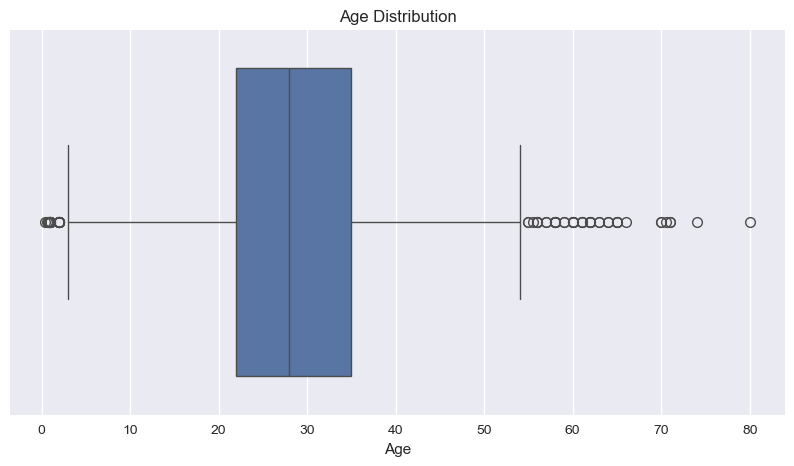

In [145]:
plt.figure(figsize=(10,5))
plt.title("Age Distribution")
sns.boxplot(data=df, x = "Age")
plt.xlabel("Age")
plt.show()

- age distribution shows wide spread
- age columns contains outliers
- 50% of passengers fall within moderate age range

#### Fare Column Distribution

In [146]:
df["Fare"].describe()

count    891.000000
mean      32.204208
std       49.693429
min        0.000000
25%        7.910400
50%       14.454200
75%       31.000000
max      512.329200
Name: Fare, dtype: float64

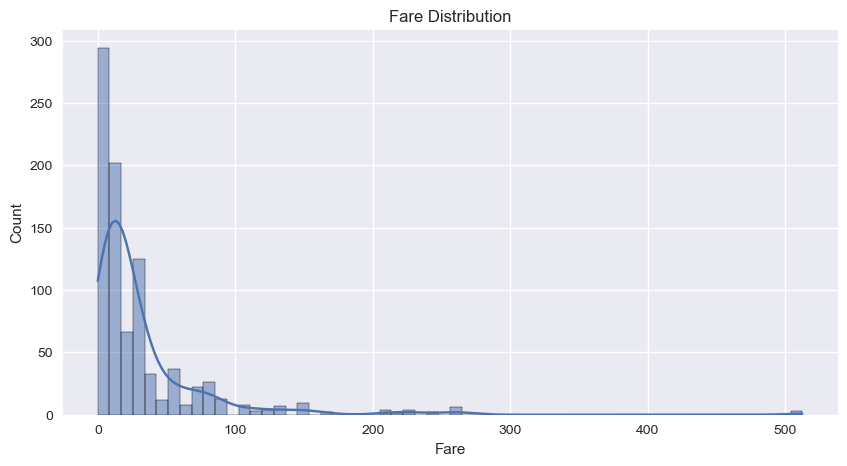

In [147]:
plt.figure(figsize=(10,5))
plt.title("Fare Distribution")
sns.histplot(data=df, x = "Fare", kde=True)
plt.xlabel("Fare")
plt.ylabel("Count")
plt.show()

- the distribution is right skewed (there are many outliers)
- small number of passengers paid very high fares
- most passengers paid low fares

#### Survived Column Distribution

In [148]:
df["Survived"].value_counts(normalize=True)*100

Survived
0    61.616162
1    38.383838
Name: proportion, dtype: float64

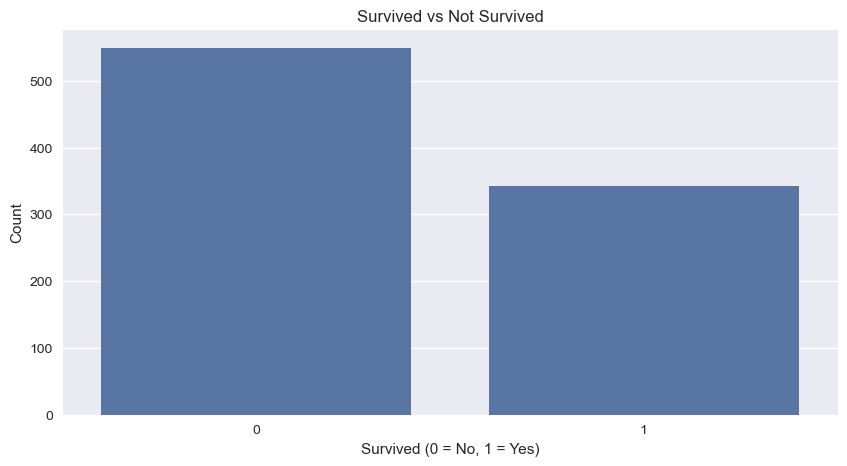

In [149]:
plt.figure(figsize=(10,5))
plt.title("Survived vs Not Survived")
sns.barplot(x=df["Survived"].value_counts().index, y=df["Survived"].value_counts())
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.show()

- number of non-survivors is higher than survivors
- survived variable is imbalanced

#### Pclass Column Distribution

In [150]:
df["Pclass"].value_counts(normalize=True)*100

Pclass
3    55.106622
1    24.242424
2    20.650954
Name: proportion, dtype: float64

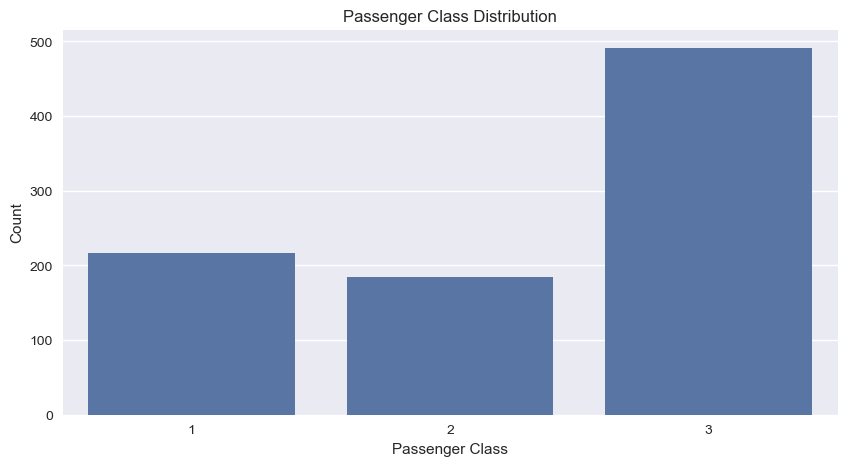

In [151]:
plt.figure(figsize=(10,5))
plt.title("Passenger Class Distribution")
sns.countplot(data=df, x="Pclass")
plt.xlabel("Passenger Class")
plt.ylabel("Count")
plt.show()

- most passengers are in the 3rd class
- 2nd class passengers are the fewest

#### Sex Column Distribution

In [152]:
df["Sex"].value_counts()

Sex
male      577
female    314
Name: count, dtype: int64

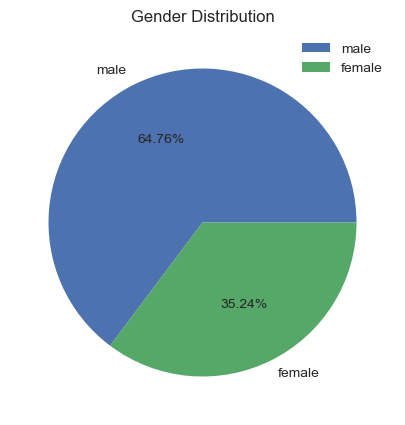

In [153]:
plt.figure(figsize=(10,5))
plt.title("Gender Distribution")
plt.pie(df["Sex"].value_counts(), labels=df["Sex"].value_counts().index, autopct="%0.2f%%")
plt.legend()
plt.show()

- number of males is higher than females

#### FamilySize Column Distribution

In [154]:
df["FamilySize"].value_counts()

FamilySize
1     537
2     161
3     102
4      29
6      22
5      15
7      12
11      7
8       6
Name: count, dtype: int64

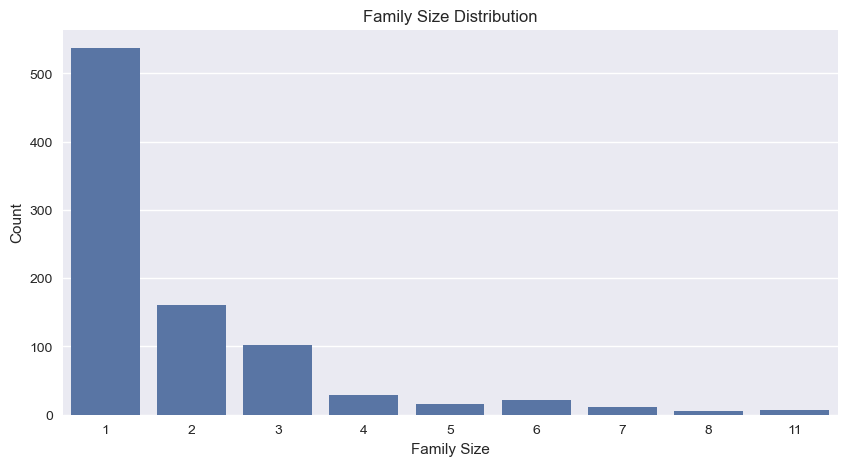

In [155]:
plt.figure(figsize=(10,5))
plt.title("Family Size Distribution")
sns.barplot(x=df["FamilySize"].value_counts().index, y=df["FamilySize"].value_counts())
plt.xlabel("Family Size")
plt.ylabel("Count")
plt.show()

- most passengers traveled alone or with small families
- large families are rare

#### Embarked Column Distribution

In [156]:
df["Embarked"].value_counts()

Embarked
S    646
C    168
Q     77
Name: count, dtype: int64

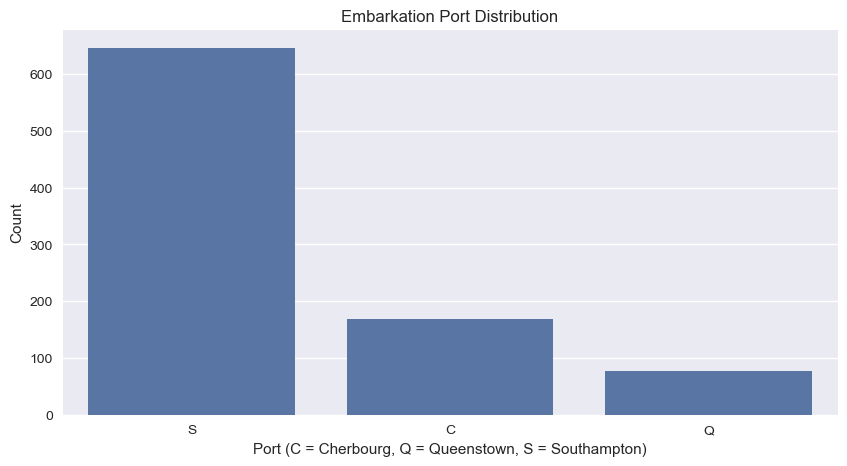

In [157]:
plt.figure(figsize=(10,5))
plt.title("Embarkation Port Distribution")
sns.barplot(x=df["Embarked"].value_counts().index, y=df["Embarked"].value_counts())
plt.xlabel("Port (C = Cherbourg, Q = Queenstown, S = Southampton)")
plt.ylabel("Count")
plt.show()

- most passengers embarked from southampton port

### Bi-Variate Analysis

#### Survived VS Sex

In [158]:
df.groupby(["Survived"])["Sex"].value_counts()

Survived  Sex   
0         male      468
          female     81
1         female    233
          male      109
Name: count, dtype: int64

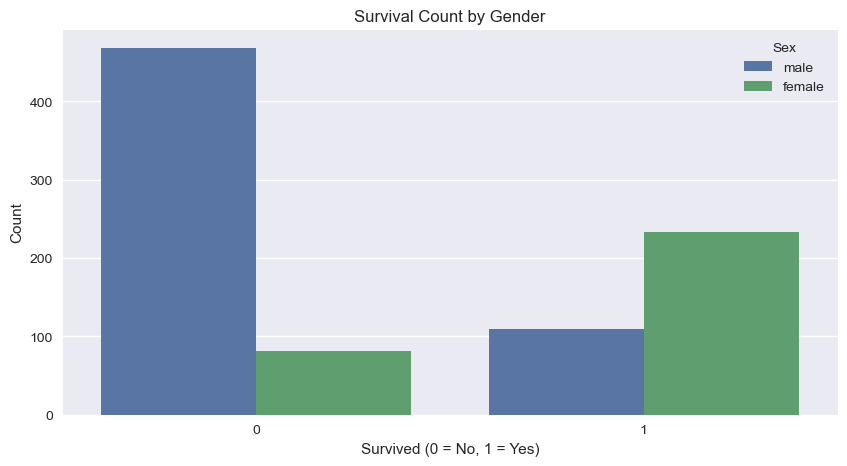

In [159]:
plt.figure(figsize=(10, 5))
plt.title("Survival Count by Gender")
sns.countplot(df, x="Survived", hue="Sex")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.show()

- females have a higher survival rate than males

#### Survived VS Age

In [160]:
df.groupby(["Survived"])["Age"].mean()

Survived
0    30.028233
1    28.291433
Name: Age, dtype: float64

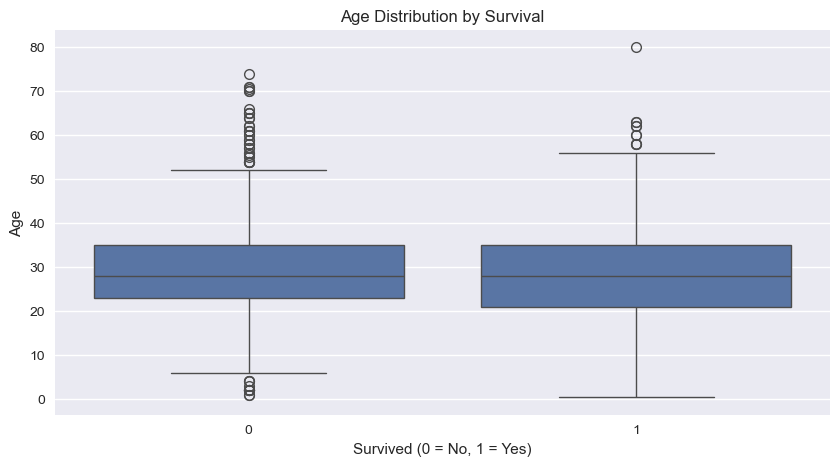

In [161]:
plt.figure(figsize=(10, 5))
plt.title("Age Distribution by Survival")
sns.boxplot(data=df, x="Survived", y="Age")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Age")
plt.show()

- age distributions are similar for survivors and non-survivors (age alone not enough)
- children have a slightly higher survival rate

#### Survived VS Pclass

In [162]:
df.groupby(["Survived"])["Pclass"].value_counts()

Survived  Pclass
0         3         372
          2          97
          1          80
1         1         136
          3         119
          2          87
Name: count, dtype: int64

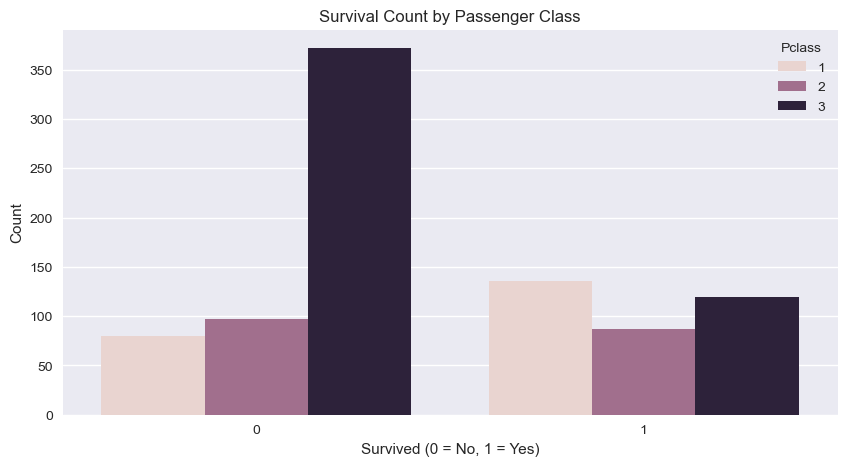

In [163]:
plt.figure(figsize=(10, 5))
plt.title("Survival Count by Passenger Class")
sns.countplot(df, x="Survived", hue="Pclass")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.show()

- 1st class passengers have higher survival rates
- 3rd class passengers have the lowest survival rates

#### Survived VS FamilySize

In [164]:
df.groupby(["Survived"])["FamilySize"].value_counts()

Survived  FamilySize
0         1             374
          2              72
          3              43
          6              19
          5              12
          4               8
          7               8
          11              7
          8               6
1         1             163
          2              89
          3              59
          4              21
          7               4
          5               3
          6               3
Name: count, dtype: int64

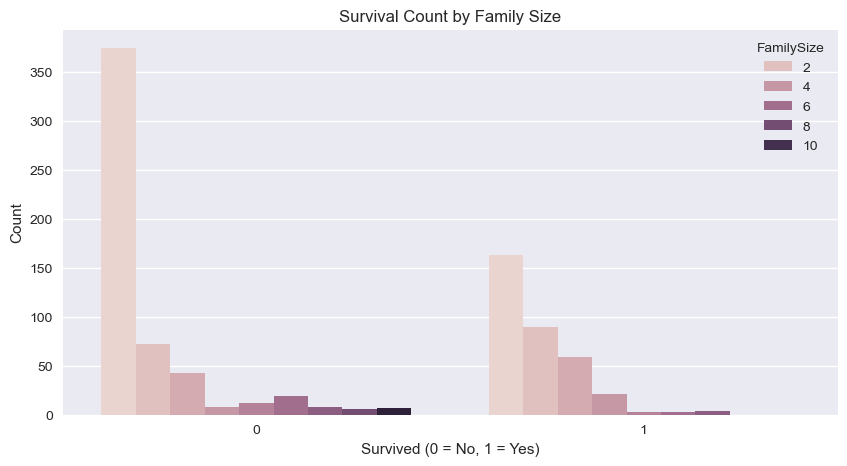

In [165]:
plt.figure(figsize=(10, 5))
plt.title("Survival Count by Family Size")
sns.countplot(data = df, x="Survived", hue="FamilySize")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.show()

- small families have higher survival rates
- very large families have lower survival rates

#### Survived VS Fare

In [166]:
df.groupby(["Survived"])["Fare"].mean()

Survived
0    22.117887
1    48.395408
Name: Fare, dtype: float64

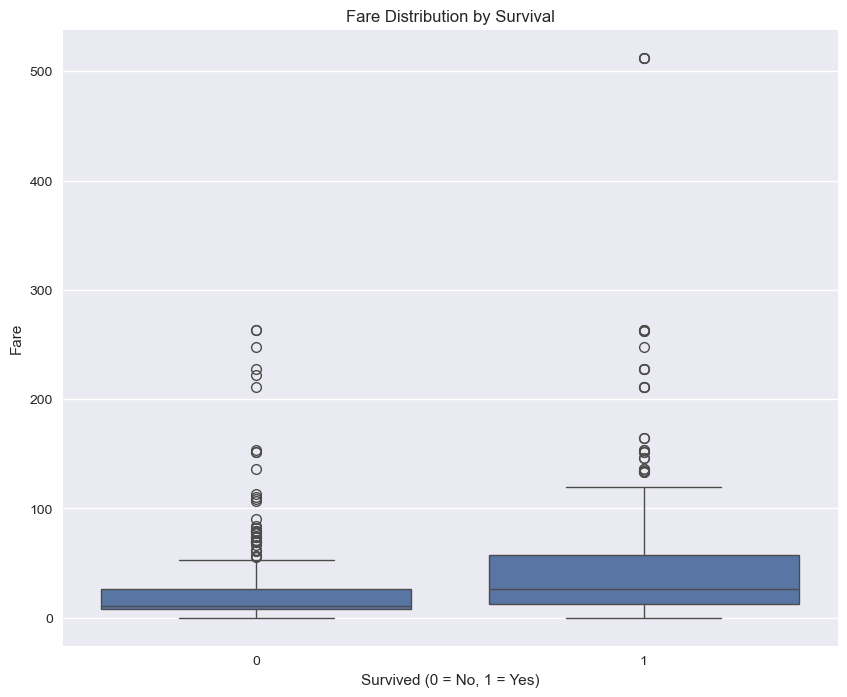

In [167]:
plt.figure(figsize=(10, 8))
plt.title("Fare Distribution by Survival")
sns.boxplot(data=df, x="Survived", y="Fare")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Fare")
plt.show()

- passengers who paid higher fares have higher survival rates

#### Survived VS Embarked

In [168]:
df.groupby(["Survived"])["Embarked"].value_counts()

Survived  Embarked
0         S           427
          C            75
          Q            47
1         S           219
          C            93
          Q            30
Name: count, dtype: int64

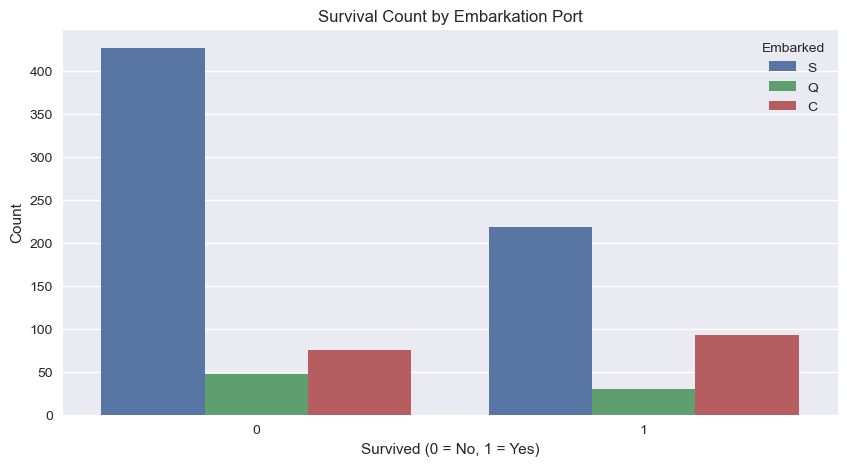

In [169]:
plt.figure(figsize=(10, 5))
plt.title("Survival Count by Embarkation Port")
sns.countplot(data = df, x="Survived", hue="Embarked")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.show()

- embarked feature has less influence compared to others

#### Pclass VS Age

In [170]:
df.groupby(["Pclass"])["Age"].mean()

Pclass
1    36.812130
2    29.765380
3    25.932627
Name: Age, dtype: float64

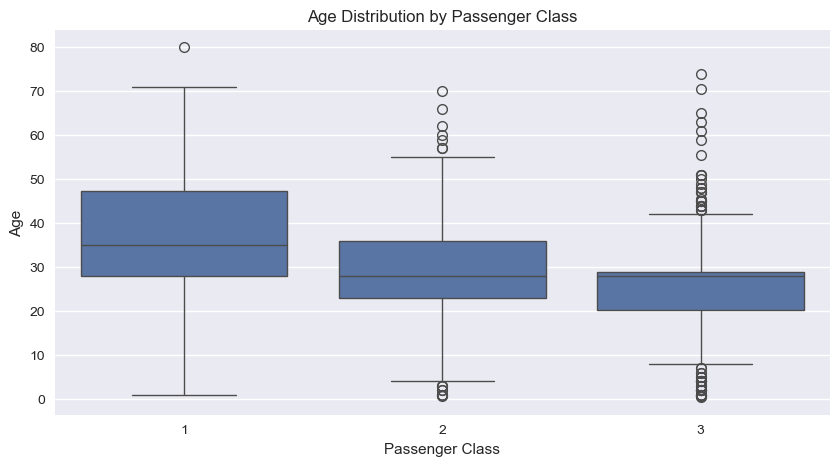

In [171]:
plt.figure(figsize=(10, 5))
plt.title("Age Distribution by Passenger Class")
sns.boxplot(data=df, x="Pclass", y="Age")
plt.xlabel("Passenger Class")
plt.ylabel("Age")
plt.show()

- older passengers are in 1st class
- 3rd class passengers are younger

#### Pclass VS Fare

In [172]:
df.groupby(["Pclass"])["Fare"].mean()

Pclass
1    84.154687
2    20.662183
3    13.675550
Name: Fare, dtype: float64

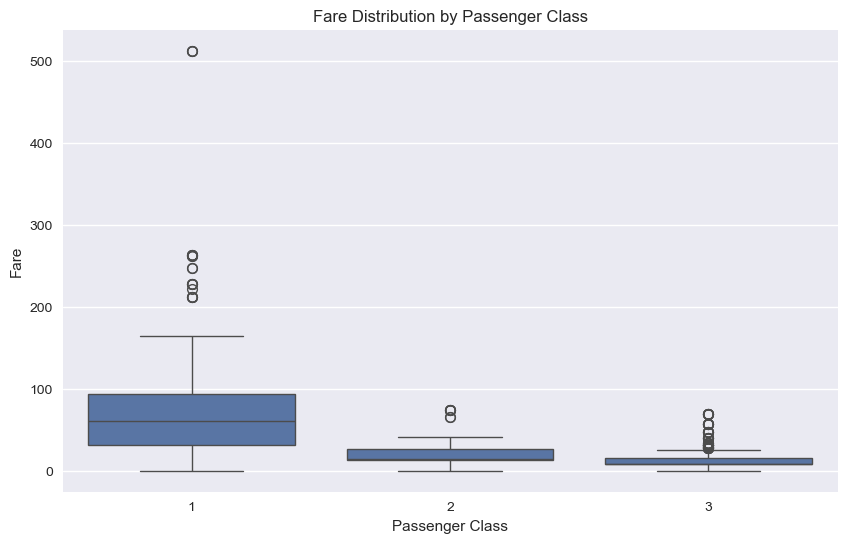

In [173]:
plt.figure(figsize=(10, 6))
plt.title("Fare Distribution by Passenger Class")
sns.boxplot(data=df, x="Pclass", y="Fare")
plt.xlabel("Passenger Class")
plt.ylabel("Fare")
plt.show()

- higher classes associated with higher fares

#### Pclass VS Sex

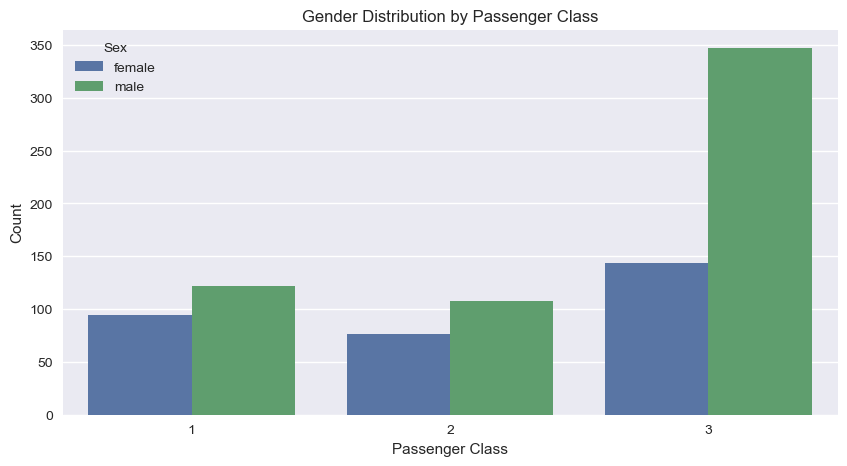

In [174]:
plt.figure(figsize=(10, 5))
plt.title("Gender Distribution by Passenger Class")
sns.countplot(data=df, x="Pclass", hue="Sex")
plt.xlabel("Passenger Class")
plt.ylabel("Count")
plt.show()

- 3rd class had the most passengers but was male-dominated, combining low class priority and gender disadvantage, making them the least likely to survive.

#### Sex VS Age

In [175]:
df.groupby(["Sex"])["Age"].mean()

Sex
female    27.929936
male      30.140676
Name: Age, dtype: float64

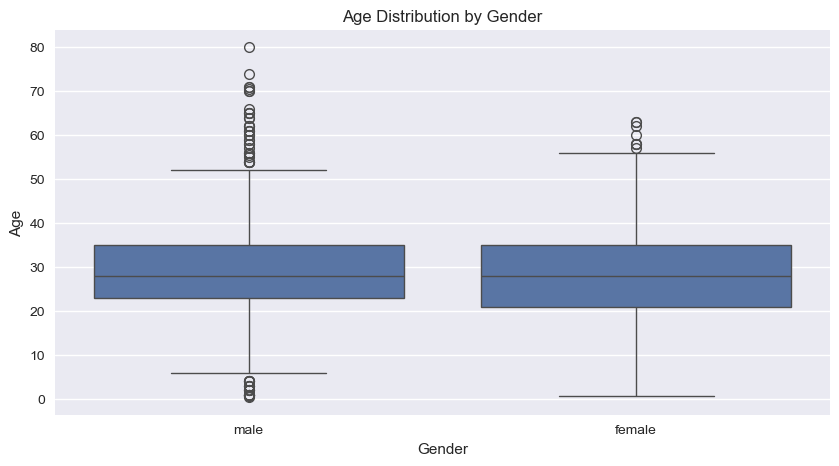

In [176]:
plt.figure(figsize=(10, 5))
plt.title("Age Distribution by Gender")
sns.boxplot(data=df, x="Sex", y="Age")
plt.xlabel("Gender")
plt.ylabel("Age")
plt.show()

- age distribution is similar for males and females

### Multi-Variate Analysis

In [177]:
df.groupby(["Pclass", "Sex"])["Survived"].mean().unstack()

Sex,female,male
Pclass,,
1,0.968085,0.368852
2,0.921053,0.157407
3,0.500000,0.135447


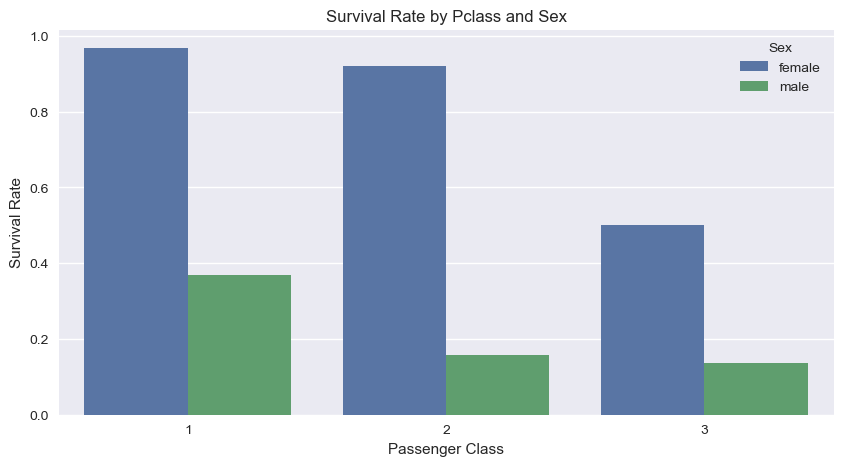

In [178]:
plt.figure(figsize=(10,5))
plt.title("Survival Rate by Pclass and Sex")
survival = df.groupby(["Pclass", "Sex"])["Survived"].mean().reset_index()
sns.barplot(data=survival, x="Pclass", y="Survived", hue="Sex")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate")
plt.show()

- females survived at much higher rates than males across all classes
- 1st class females had the highest survival rate while 3rd class males had the lowest
- the class effect is stronger for females
    - 1st class females vs 3rd class females shows a big drop, while males show less variation across classes

---------------------------

## Key Findings

- 38% only survived → data is imbalanced
- Females survived at much higher rates than males
- 1st class passengers had the highest survival rates
- Higher fare = higher chance of survival
- Solo travelers and small families survived more than large families